# Cadenas de Markov de Tiempo Continuo
## Introducción, Tasas de Transición y Matriz Q

---

**Modelado bajo Incertidumbre**  
Departamento de Ingeniería Industrial · Universidad de los Andes  
*Semana 7 · Módulo 2*

## Agenda

1. ¿Qué es una Cadena de Markov de Tiempo Continuo?
2. Propiedad sin memoria
3. Tasas de transición
4. Matriz Generadora **Q**
5. Ejemplo: sistema con 3 estados


## ¿Qué es una CTMC?

Una **Cadena de Markov de Tiempo Continuo** (CTMC) es un proceso estocástico $\{X(t),\; t \geq 0\}$ con:

- **Espacio de estados discreto**: $S = \{0, 1, 2, \ldots, N\}$
- **Tiempo continuo**: $t \in [0, \infty)$
- **Propiedad de Markov** (sin memoria):

$$P\big(X(t+s) = j \mid X(s) = i,\; X(u) = x_u,\; u < s\big) = P\big(X(t+s) = j \mid X(s) = i\big)$$

El tiempo de permanencia en cada estado $i$ sigue una distribución **Exponencial** con tasa $\nu_i$.

## Propiedad sin memoria

La distribución exponencial es la **única** distribución continua sin memoria:

$$P(T > t + s \mid T > s) = P(T > t)$$

Esto garantiza que el proceso no recuerda cuánto tiempo lleva en el estado actual.

> **Ejemplo**: Si una máquina lleva 5 horas funcionando, la probabilidad de que falle en la próxima hora es la misma que si acabara de encenderse.

## Tasas de Transición

La tasa de transición $q_{ij}$ representa la **intensidad** de ir del estado $i$ al estado $j$:

$$q_{ij} = \lim_{h \to 0} \frac{P(X(t+h)=j \mid X(t)=i)}{h}, \quad i \neq j$$

La **tasa de salida total** del estado $i$ es:

$$\nu_i = \sum_{j \neq i} q_{ij}$$

El tiempo de permanencia en $i$ es $T_i \sim \text{Exp}(\nu_i)$, con media $1/\nu_i$.

## La Matriz Generadora Q

La **matriz generadora** (o matriz de tasas) $Q$ tiene dimensión $N \times N$:

$$Q = \begin{pmatrix} -\nu_0 & q_{01} & q_{02} & \cdots \\ q_{10} & -\nu_1 & q_{12} & \cdots \\ \vdots & & \ddots & \\ q_{N0} & \cdots & & -\nu_N \end{pmatrix}$$

**Propiedades clave:**
- Diagonal: $q_{ii} = -\nu_i = -\sum_{j \neq i} q_{ij} \leq 0$
- Fuera de diagonal: $q_{ij} \geq 0$
- Cada **fila suma cero**: $\sum_j q_{ij} = 0$

## Ejemplo: Sistema con 3 estados

In [16]:
# Matriz Q para un sistema con 3 estados {0, 1, 2}
# Estado 0: Idle, Estado 1: Ocupado, Estado 2: Saturado
Q = np.array([
    [-3,   2,   1 ],   # desde estado 0
    [ 4,  -6,   2 ],   # desde estado 1
    [ 1,   3,  -4 ]    # desde estado 2
], dtype=float)

print("Matriz Q:")
print(Q)
print("\nVerificacion (filas deben sumar 0):", Q.sum(axis=1))

Matriz Q:
[[-3.  2.  1.]
 [ 4. -6.  2.]
 [ 1.  3. -4.]]

Verificacion (filas deben sumar 0): [0. 0. 0.]


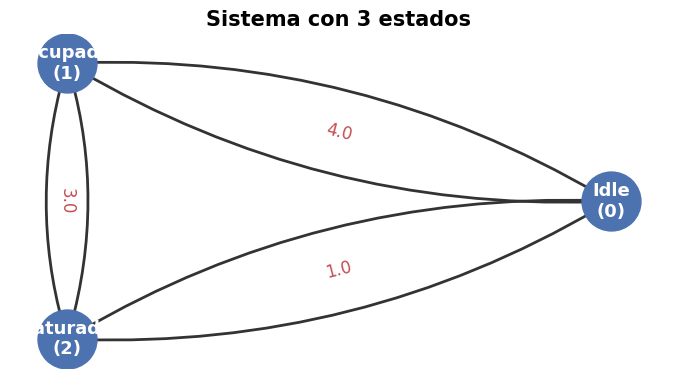

In [5]:
def plot_ctmc_diagram(Q, state_labels, title="Diagrama de Tasas de Transicion", ax=None):
    n = len(state_labels)
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    edge_labels = {}
    for i in range(n):
        for j in range(n):
            if i != j and Q[i, j] > 0:
                G.add_edge(i, j, weight=Q[i, j])
                edge_labels[(i, j)] = f"{Q[i,j]:.1f}"
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    pos = nx.circular_layout(G)
    nx.draw_networkx_nodes(G, pos, node_size=1800, node_color='#4C72B0', ax=ax)
    nx.draw_networkx_labels(G, pos, labels={i: state_labels[i] for i in range(n)},
                            font_color='white', font_size=13, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=20,
                           edge_color='#333333', width=2,
                           connectionstyle='arc3,rad=0.15', ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                  font_size=12, font_color='#C44E52', ax=ax)
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.axis('off')

fig, ax = plt.subplots(figsize=(7, 4))
plot_ctmc_diagram(Q, ['Idle\n(0)', 'Ocupado\n(1)', 'Saturado\n(2)'],
                  title="Sistema con 3 estados", ax=ax)
plt.tight_layout()
plt.show()